In [1]:
import pandas as pd
import seaborn as sns
import os
from sklearn.preprocessing import MinMaxScaler
#读取附件信息
attachments1_path = '附件1.xlsx'
attachments2_path = '附件2.xlsx'

In [2]:
#读取附件1信息
attachments1_sheet1 = pd.read_excel(attachments1_path, sheet_name=0)
attachments1_sheet2 = pd.read_excel(attachments1_path, sheet_name=1)
#读取附件2信息
attachments2_sheet1 = pd.read_excel(attachments2_path, sheet_name=0)
attachments2_sheet2 = pd.read_excel(attachments2_path, sheet_name=1)

In [7]:
attachments2_sheet1=attachments2_sheet1.fillna(method='ffill')

,种植地块,作物编号,作物名称,作物类型,种植面积/亩,种植季次
0,A1,6,小麦,粮食,80.0,单季
1,A2,7,玉米,粮食,55.0,单季
2,A3,7,玉米,粮食,35.0,单季
3,A4,1,黄豆,粮食（豆类）,72.0,单季
4,A5,4,绿豆,粮食（豆类）,68.0,单季
...,...,...,...,...,...,...
82,F3,28,小青菜,蔬菜,0.3,第二季
83,F3,30,生菜,蔬菜,0.3,第二季
84,F4,19,芸豆,蔬菜（豆类）,0.6,第一季
85,F4,34,芹菜,蔬菜,0.3,第二季


In [ ]:
# 合并两个数据框，按'作物编号'进行合并
merged_df = pd.merge(attachments2_sheet1, attachments2_sheet2, on='作物编号', how='inner')
# 删除重复命名的列，例如土地_x，土地_y
# 通过找出重复列并删除
# 合并数据
merged_df = pd.merge(attachments2_sheet1, attachments2_sheet2, on='作物编号', suffixes=('_x', '_y'))

# 处理重复列名，只保留'_x'后缀的列，并删除'_x'后缀
columns_to_keep = [col for col in merged_df.columns if col.endswith('_x')]
columns_to_keep = [col.replace('_x', '') for col in columns_to_keep]

# 保留'_x'后缀的列，并删除'_y'后缀的列
columns_to_drop = [col for col in merged_df.columns if col.endswith('_y')]

# 删除'_y'后缀的列
merged_df = merged_df.drop(columns=columns_to_drop)

# 重命名'_x'后缀的列
merged_df.columns = [col.replace('_x', '') for col in merged_df.columns]

In [10]:
# 添加销售量/斤列
if '亩产量/斤' in merged_df.columns and '销售单价/(元/斤)' in merged_df.columns:
    merged_df['销售量/斤'] = merged_df['亩产量/斤'] * merged_df['种植面积/亩']

In [12]:
merged_df.to_excel('merged_file_with_sales.xlsx', index=False)

In [13]:
sales_merged_df = merged_df.groupby('作物名称').agg({'销售量/斤': 'sum'}).reset_index()

In [15]:
sales_merged_df .to_excel('各农作物总销售量.xlsx', index=False)

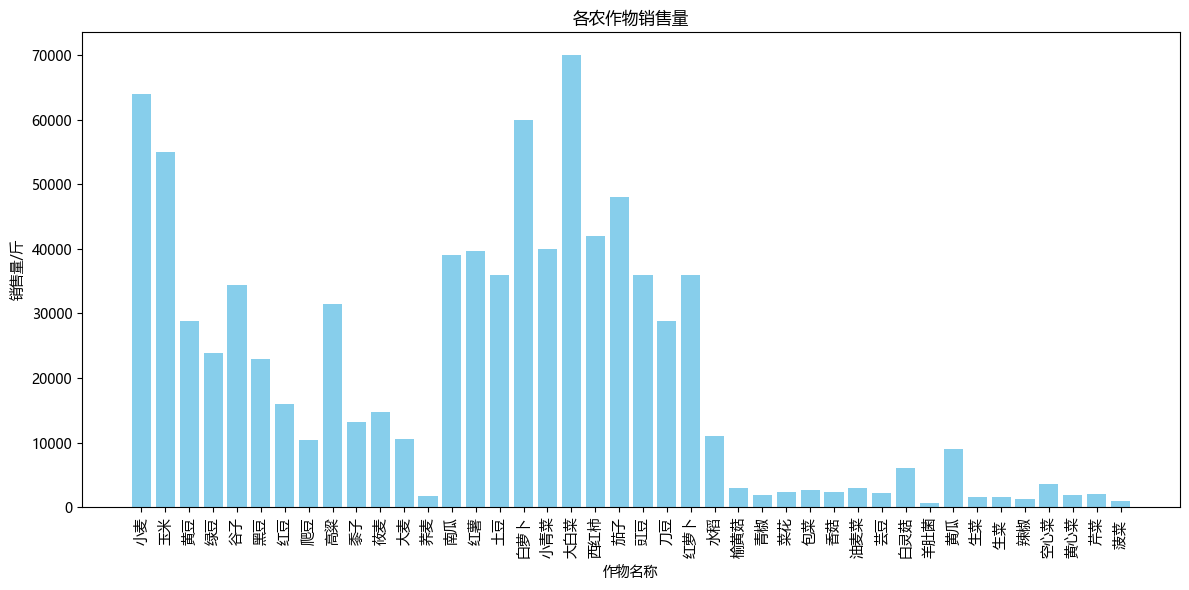

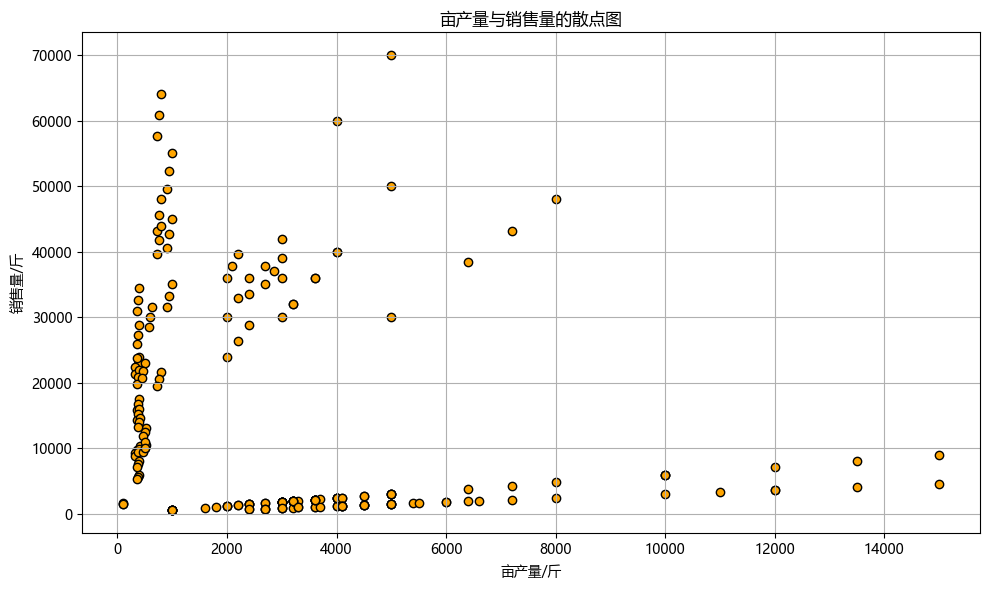

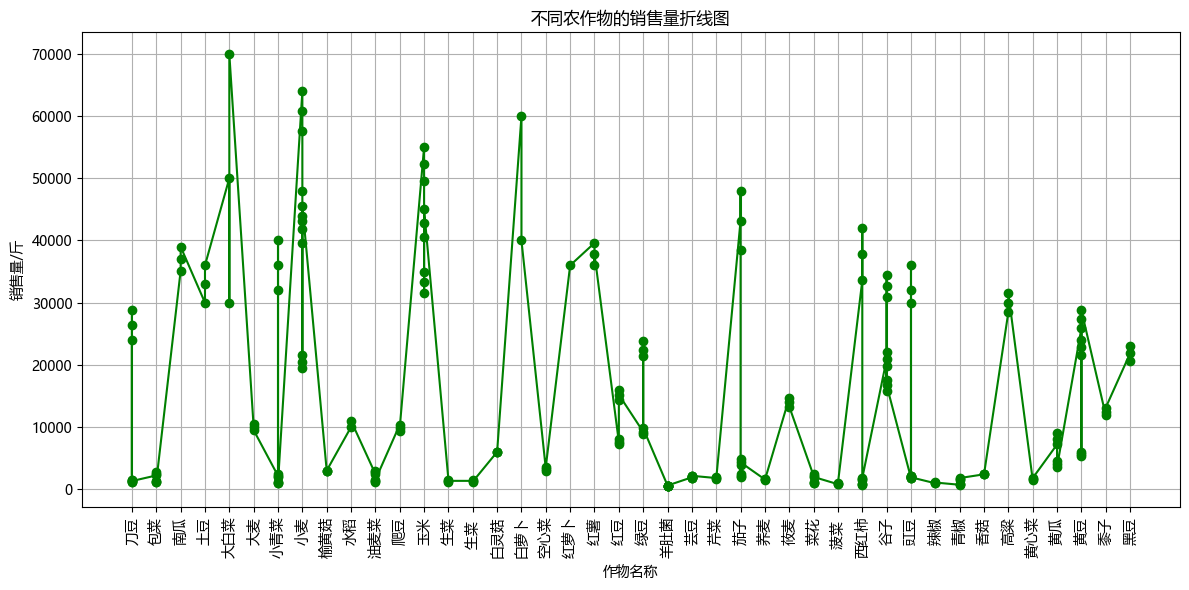

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei'] 
plt.rcParams['axes.unicode_minus'] = False 
# 读取合并后的数据
sales_merged_df = pd.read_excel('merged_file_with_sales.xlsx')

# 绘制柱状图（以作物名称为x轴，销售量/斤为y轴）
plt.figure(figsize=(12, 6))
plt.bar(sales_merged_df['作物名称'], sales_merged_df['销售量/斤'], color='skyblue')
plt.xticks(rotation=90)  # 旋转x轴标签以便于阅读
plt.title('各农作物销售量')
plt.xlabel('作物名称')
plt.ylabel('销售量/斤')
plt.tight_layout()
plt.savefig('2023年各农作物销售量.png')
plt.show()

# 绘制散点图（以亩产量/斤为x轴，销售量/斤为y轴）
plt.figure(figsize=(10, 6))
plt.scatter(sales_merged_df['亩产量/斤'], sales_merged_df['销售量/斤'], c='orange', edgecolor='k')
plt.title('亩产量与销售量的散点图')
plt.xlabel('亩产量/斤')
plt.ylabel('销售量/斤')
plt.grid(True)
plt.tight_layout()
plt.savefig('亩产量与销售量的散点图.png')
plt.show()

# 绘制折线图（以作物名称为x轴，销售量/斤为y轴，按作物名称排序）
plt.figure(figsize=(12, 6))
sales_merged_df_sorted = sales_merged_df.sort_values(by='作物名称')
plt.plot(sales_merged_df_sorted['作物名称'], sales_merged_df_sorted['销售量/斤'], marker='o', linestyle='-', color='green')
plt.xticks(rotation=90)  # 旋转x轴标签以便于阅读
plt.title('不同农作物的销售量折线图')
plt.xlabel('作物名称')
plt.ylabel('销售量/斤')
plt.grid(True)
plt.tight_layout()
plt.savefig('不同农作物的销售量折线图.png')
plt.show()



In [17]:
merged_df

,种植地块,作物编号,作物名称,作物类型,种植面积/亩,种植季次,序号,地块类型,亩产量/斤,种植成本/(元/亩),销售单价/(元/斤),销售量/斤
0,A1,6,小麦,粮食,80.0,单季,6,平旱地,800.0,450.0,3.00-4.00,64000.0
1,A1,6,小麦,粮食,80.0,单季,21,梯田,760.0,450.0,3.00-4.00,60800.0
2,A1,6,小麦,粮食,80.0,单季,36,山坡地,720.0,450.0,3.00-4.00,57600.0
3,B1,6,小麦,粮食,60.0,单季,6,平旱地,800.0,450.0,3.00-4.00,48000.0
4,B1,6,小麦,粮食,60.0,单季,21,梯田,760.0,450.0,3.00-4.00,45600.0
...,...,...,...,...,...,...,...,...,...,...,...,...
208,F4,34,芹菜,蔬菜,0.3,第二季,82,普通大棚,6600.0,1100.0,3.20-4.80,1980.0
209,F4,34,芹菜,蔬菜,0.3,第二季,107,智慧大棚,6000.0,1200.0,3.80-5.80,1800.0
210,F4,23,菠菜,蔬菜,0.3,第二季,53,水浇地,2700.0,2300.0,4.80-6.70,810.0
211,F4,23,菠菜,蔬菜,0.3,第二季,71,普通大棚,3300.0,2700.0,4.80-6.70,990.0


# 通过上述列表进行分析可知 相同农作物的销售单价在不同的地块类型中所售出的价格也并不相同 
# 我们想采用加权平均的方法得到每一个农作物的销售单价 从而解决相同农作物的单价不一致的问题

In [18]:
import numpy as np
def calculate_final_price(row):
    # 提取销售单价的最小值和最大值
    price_range = row['销售单价/(元/斤)'].split('-')
    min_price = float(price_range[0])
    max_price = float(price_range[1])
    
    # 计算销售单价的平均值
    avg_price = (min_price + max_price) / 2
    
    # 添加随机浮动（假设浮动范围为 ±10%）
    random_fluctuation = np.random.uniform(-0.1, 0.1) * avg_price
    
    # 计算最终价格
    final_price = avg_price + random_fluctuation
    
    return final_price

# 读取数据
df =  merged_df

# 应用函数逐行计算
df['最终销售价格/(元/斤)'] = df.apply(calculate_final_price, axis=1)

In [19]:
df

,种植地块,作物编号,作物名称,作物类型,种植面积/亩,种植季次,序号,地块类型,亩产量/斤,种植成本/(元/亩),销售单价/(元/斤),销售量/斤,最终销售价格/(元/斤)
0,A1,6,小麦,粮食,80.0,单季,6,平旱地,800.0,450.0,3.00-4.00,64000.0,3.404922
1,A1,6,小麦,粮食,80.0,单季,21,梯田,760.0,450.0,3.00-4.00,60800.0,3.463306
2,A1,6,小麦,粮食,80.0,单季,36,山坡地,720.0,450.0,3.00-4.00,57600.0,3.579677
3,B1,6,小麦,粮食,60.0,单季,6,平旱地,800.0,450.0,3.00-4.00,48000.0,3.503006
4,B1,6,小麦,粮食,60.0,单季,21,梯田,760.0,450.0,3.00-4.00,45600.0,3.279718
...,...,...,...,...,...,...,...,...,...,...,...,...,...
208,F4,34,芹菜,蔬菜,0.3,第二季,82,普通大棚,6600.0,1100.0,3.20-4.80,1980.0,4.043436
209,F4,34,芹菜,蔬菜,0.3,第二季,107,智慧大棚,6000.0,1200.0,3.80-5.80,1800.0,4.639435
210,F4,23,菠菜,蔬菜,0.3,第二季,53,水浇地,2700.0,2300.0,4.80-6.70,810.0,5.544702
211,F4,23,菠菜,蔬菜,0.3,第二季,71,普通大棚,3300.0,2700.0,4.80-6.70,990.0,5.817274


In [20]:
df = df.groupby('作物名称').agg({'最终销售价格/(元/斤)': 'mean','销售量/斤': 'sum'}).reset_index()

In [21]:
df

,作物名称,最终销售价格/(元/斤),销售量/斤
0,刀豆,7.228614,87120.0
1,包菜,6.607019,11070.0
2,南瓜,1.489835,111150.0
3,土豆,3.835782,99000.0
4,大白菜,2.546458,150000.0
5,大麦,3.474102,30000.0
6,小青菜,6.143419,117720.0
7,小麦,3.510632,506160.0
8,榆黄菇,57.516747,9000.0
9,水稻,7.004052,21000.0


# 在此基础上 我们对附件数据集是否为豆类进行添加一列 用于后续的约束条件(有一个约束条件为是否为豆类)

In [22]:
df2=pd.read_excel('初始数据未进行计算单价.xlsx')

In [23]:
df2.head()

,序号,作物编号,作物名称,地块类型,种植季次,亩产量/斤,种植成本/(元/亩),销售单价/(元/斤),种植面积/亩,作物类型,是否豆类
0,1,1,黄豆,平旱地,单季,400,400,2.50-4.00,72.0,粮食,是
1,2,2,黑豆,平旱地,单季,500,400,6.50-8.50,0.0,粮食,是
2,3,3,红豆,平旱地,单季,400,350,7.50-9.00,0.0,粮食,是
3,4,4,绿豆,平旱地,单季,350,350,6.00-8.00,68.0,粮食,是
4,5,5,爬豆,平旱地,单季,415,350,6.00-7.50,0.0,粮食,是


In [24]:
#  利用写好的滚动价格函数对作物的销售价格进行计算 从而消去区间价格
df2['加权销售价格/(元/斤)'] = df2.apply(calculate_final_price, axis=1)

In [25]:
df2

,序号,作物编号,作物名称,地块类型,种植季次,亩产量/斤,种植成本/(元/亩),销售单价/(元/斤),种植面积/亩,作物类型,是否豆类,加权销售价格/(元/斤)
0,1,1,黄豆,平旱地,单季,400,400,2.50-4.00,72.0,粮食,是,3.121511
1,2,2,黑豆,平旱地,单季,500,400,6.50-8.50,0.0,粮食,是,7.192318
2,3,3,红豆,平旱地,单季,400,350,7.50-9.00,0.0,粮食,是,7.942324
3,4,4,绿豆,平旱地,单季,350,350,6.00-8.00,68.0,粮食,是,6.833647
4,5,5,爬豆,平旱地,单季,415,350,6.00-7.50,0.0,粮食,是,6.245267
...,...,...,...,...,...,...,...,...,...,...,...,...
120,121,30,生菜,智慧大棚,第一季,5000,2000,4.50-6.00,0.3,蔬菜,不是,5.743780
121,122,31,辣椒,智慧大棚,第一季,2000,1200,6.00-8.50,0.0,蔬菜,不是,6.921743
122,123,32,空心菜,智慧大棚,第一季,12000,5000,3.00-6.00,0.3,蔬菜,不是,4.479198
123,124,33,黄心菜,智慧大棚,第一季,6000,2500,4.00-5.00,0.3,蔬菜,不是,4.426300


In [26]:
# 进一步计算各作物的销量、成本、盈利情况
# 计算总销量、总成本和总盈利情况
df2['总销量'] = df2['种植面积/亩'] * df2['亩产量/斤']
df2['总成本'] = df2['种植成本/(元/亩)'] * df2['种植面积/亩']
df2['总产量'] = df2['总销量']

In [27]:
df2

,序号,作物编号,作物名称,地块类型,种植季次,亩产量/斤,种植成本/(元/亩),销售单价/(元/斤),种植面积/亩,作物类型,是否豆类,加权销售价格/(元/斤),总销量,总成本,总产量
0,1,1,黄豆,平旱地,单季,400,400,2.50-4.00,72.0,粮食,是,3.121511,28800.0,28800.0,28800.0
1,2,2,黑豆,平旱地,单季,500,400,6.50-8.50,0.0,粮食,是,7.192318,0.0,0.0,0.0
2,3,3,红豆,平旱地,单季,400,350,7.50-9.00,0.0,粮食,是,7.942324,0.0,0.0,0.0
3,4,4,绿豆,平旱地,单季,350,350,6.00-8.00,68.0,粮食,是,6.833647,23800.0,23800.0,23800.0
4,5,5,爬豆,平旱地,单季,415,350,6.00-7.50,0.0,粮食,是,6.245267,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
120,121,30,生菜,智慧大棚,第一季,5000,2000,4.50-6.00,0.3,蔬菜,不是,5.743780,1500.0,600.0,1500.0
121,122,31,辣椒,智慧大棚,第一季,2000,1200,6.00-8.50,0.0,蔬菜,不是,6.921743,0.0,0.0,0.0
122,123,32,空心菜,智慧大棚,第一季,12000,5000,3.00-6.00,0.3,蔬菜,不是,4.479198,3600.0,1500.0,3600.0
123,124,33,黄心菜,智慧大棚,第一季,6000,2500,4.00-5.00,0.3,蔬菜,不是,4.426300,1800.0,750.0,1800.0


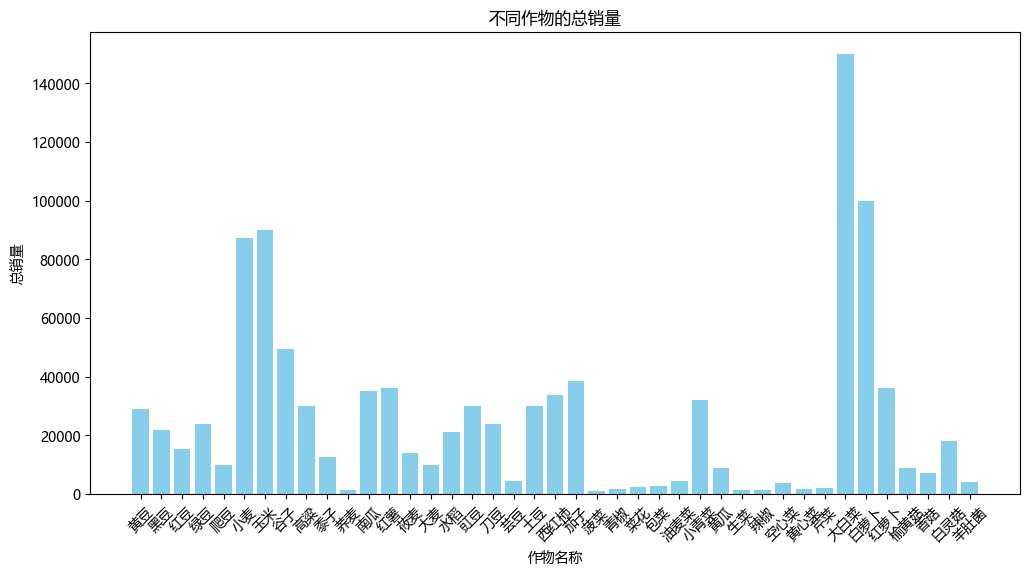

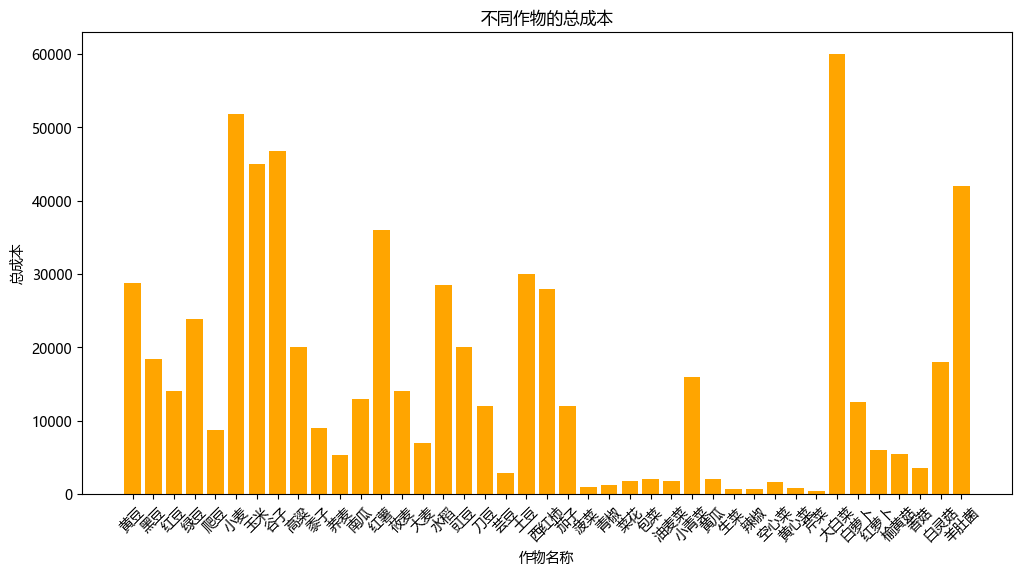

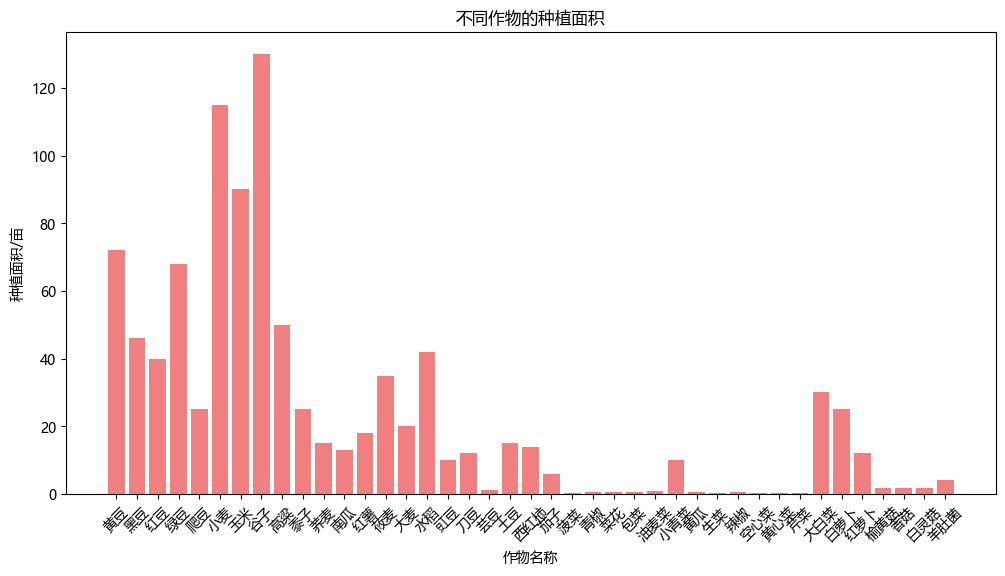

In [28]:
# 创建保存路径
def save_plot(filename):
    plt.savefig(filename, bbox_inches='tight')
    

# 绘制不同作物的总销量条形图
plt.figure(figsize=(12, 6))
plt.bar(df2['作物名称'], df2['总销量'], color='skyblue')
plt.xlabel('作物名称')
plt.ylabel('总销量')
plt.title('不同作物的总销量')
plt.xticks(rotation=45)
save_plot('total_sales_by_crop.png')

# 绘制不同作物的总成本条形图
plt.figure(figsize=(12, 6))
plt.bar(df2['作物名称'], df2['总成本'], color='orange')
plt.xlabel('作物名称')
plt.ylabel('总成本')
plt.title('不同作物的总成本')
plt.xticks(rotation=45)
save_plot('total_cost_by_crop.png')

# 绘制不同作物的种植面积条形图
plt.figure(figsize=(12, 6))
plt.bar(df2['作物名称'], df2['种植面积/亩'], color='lightcoral')
plt.xlabel('作物名称')
plt.ylabel('种植面积/亩')
plt.title('不同作物的种植面积')
plt.xticks(rotation=45)
save_plot('planting_area_by_crop.png')

# 不同作物类型的种植面积

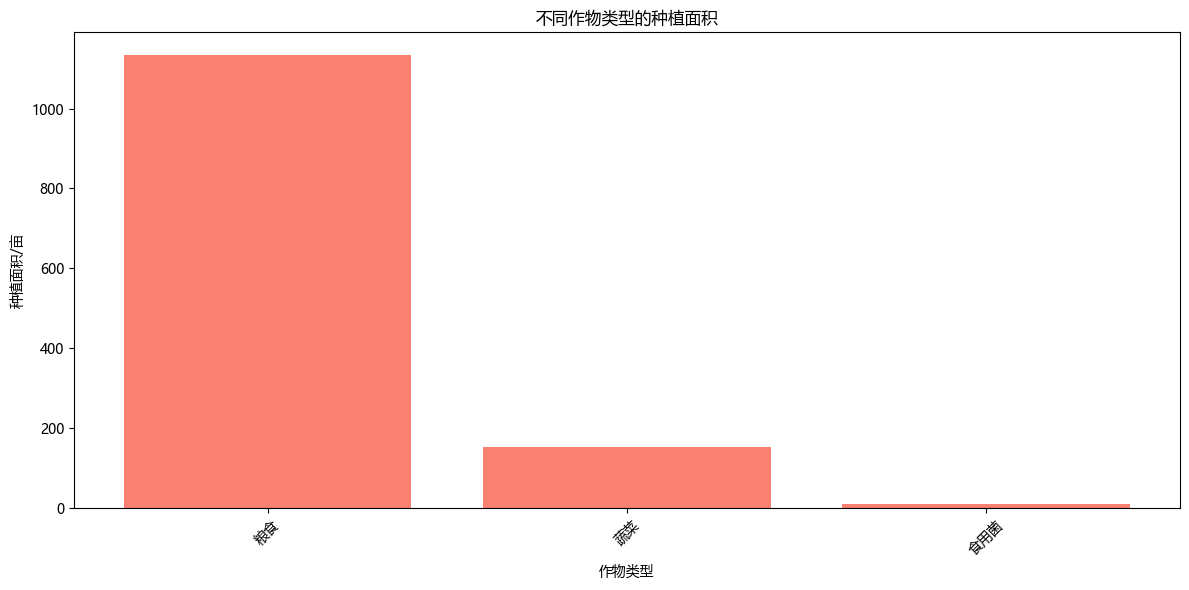

In [29]:
# 计算不同作物类型的种植面积总和
crop_type_area = df2.groupby('作物类型')['种植面积/亩'].sum()

# 绘制种植面积图
plt.figure(figsize=(12, 6))
plt.bar(crop_type_area.index, crop_type_area.values, color='salmon')
plt.title('不同作物类型的种植面积')
plt.xlabel('作物类型')
plt.ylabel('种植面积/亩')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('crop_type_area.png')  # 保存图像
plt.show()


# 绘制不同地块类型的总销量

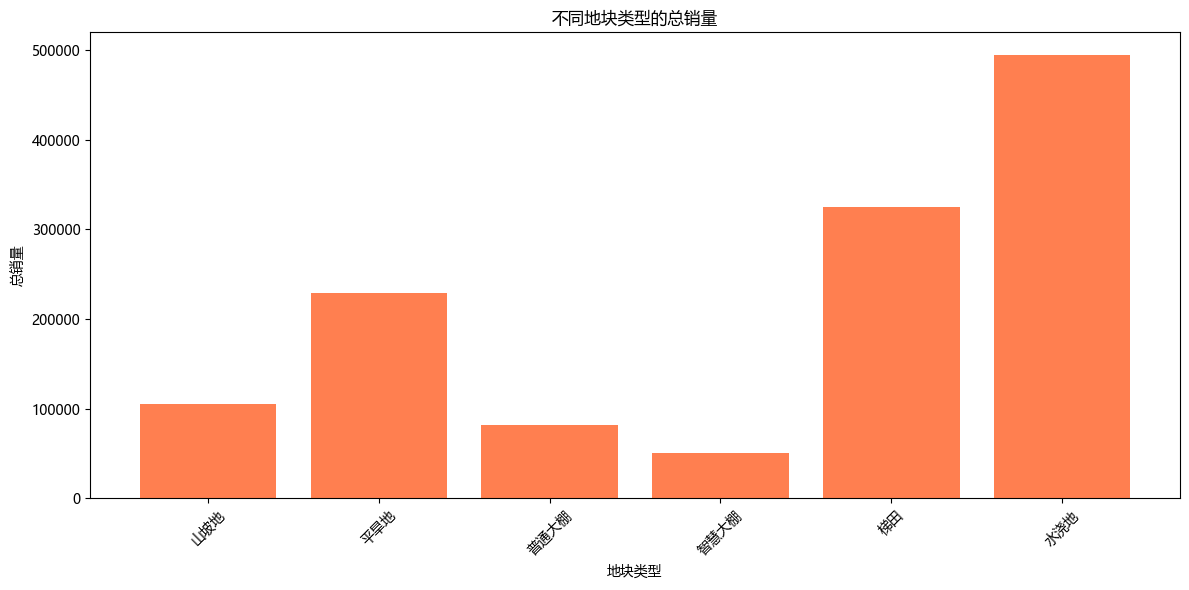

In [30]:
# 计算不同地块类型的总销量和总盈利总和
plot_type_sales = df2.groupby('地块类型')['总销量'].sum()


# 绘制地块类型的总销量图
plt.figure(figsize=(12, 6))
plt.bar(plot_type_sales.index, plot_type_sales.values, color='coral')
plt.title('不同地块类型的总销量')
plt.xlabel('地块类型')
plt.ylabel('总销量')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('plot_type_sales.png')  # 保存图像
plt.show()



In [32]:
# 计算相关系数矩阵
# 计算相关系数矩阵

corr = df2.select_dtypes(include=['float64', 'int64']).corr()

# TODO 

<Figure size 1400x1200 with 0 Axes>

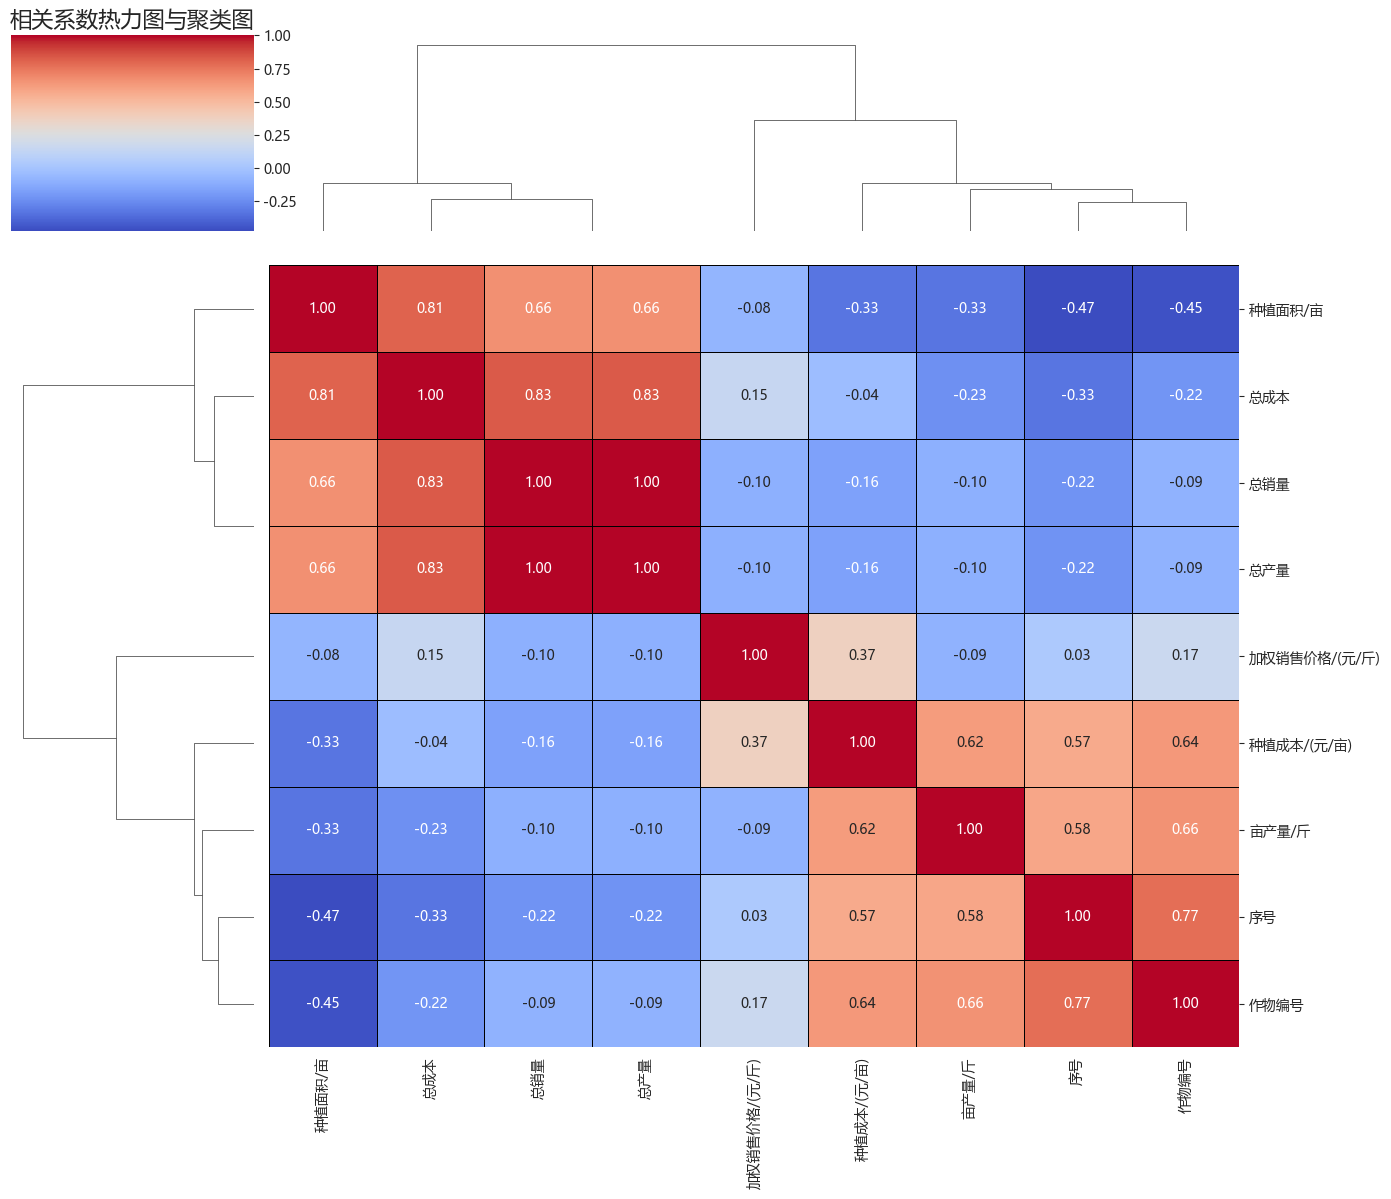

In [33]:
# 设置画布和大小
plt.figure(figsize=(14, 12))

# 绘制带有聚类的热力图
sns.clustermap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, linecolor='black', figsize=(14, 12))

# 设置标题
plt.title('相关系数热力图与聚类图', fontsize=16)

# 保存图像
plt.tight_layout()
plt.savefig('correlation_clustermap.png')

# 显示图像
plt.show()


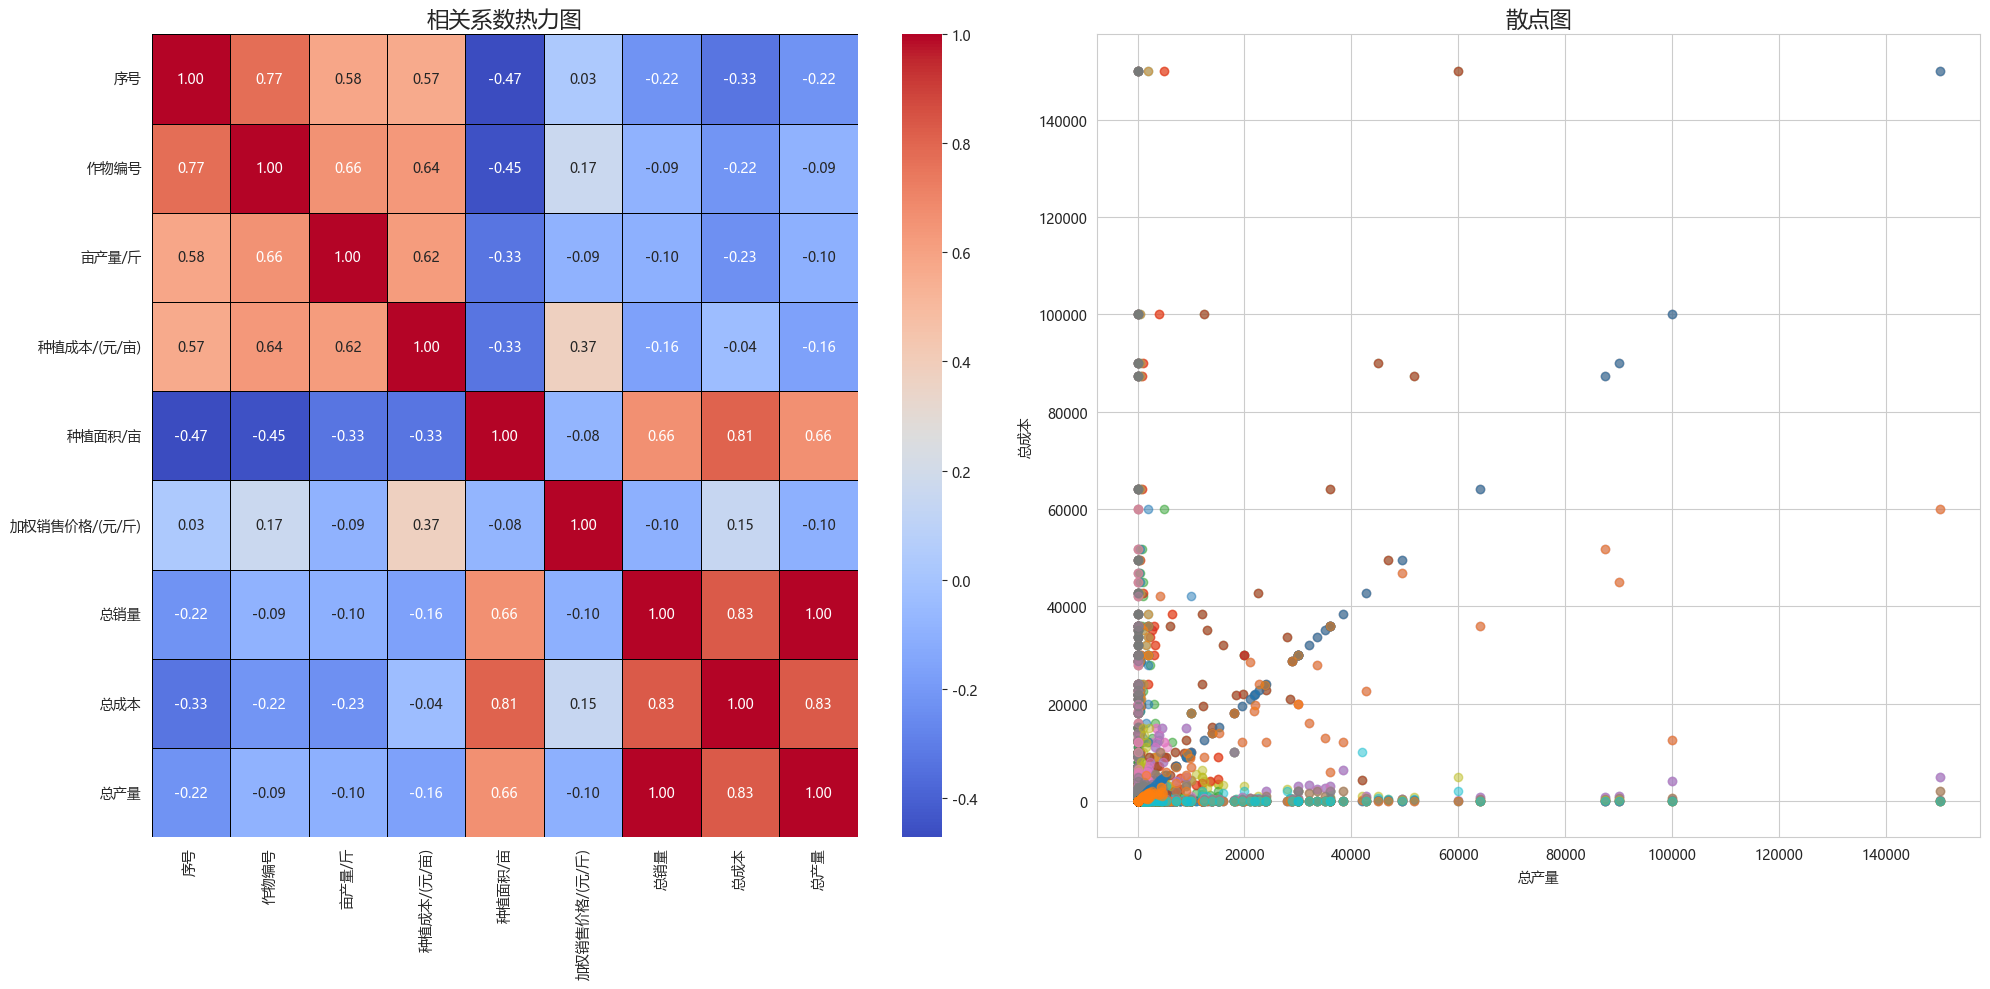

In [34]:
# 创建画布和子图
fig, ax = plt.subplots(1, 2, figsize=(20, 10))

# 绘制热力图
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, linecolor='black', ax=ax[0])
ax[0].set_title('相关系数热力图', fontsize=16)

# 绘制散点图
# 示例数据散点图
for column in corr.columns:
    for row in corr.index:
        if column != row:
            ax[1].scatter(df2[column], df2[row], alpha=0.5)
            ax[1].set_xlabel(column)
            ax[1].set_ylabel(row)
            ax[1].set_title('散点图', fontsize=16)

# 调整布局
plt.tight_layout()

# 保存图像
plt.savefig('correlation_heatmap_scatter.png')

# 显示图像
plt.show()


In [35]:
df2

,序号,作物编号,作物名称,地块类型,种植季次,亩产量/斤,种植成本/(元/亩),销售单价/(元/斤),种植面积/亩,作物类型,是否豆类,加权销售价格/(元/斤),总销量,总成本,总产量
0,1,1,黄豆,平旱地,单季,400,400,2.50-4.00,72.0,粮食,是,3.120676,28800.0,28800.0,28800.0
1,2,2,黑豆,平旱地,单季,500,400,6.50-8.50,0.0,粮食,是,7.153864,0.0,0.0,0.0
2,3,3,红豆,平旱地,单季,400,350,7.50-9.00,0.0,粮食,是,8.852348,0.0,0.0,0.0
3,4,4,绿豆,平旱地,单季,350,350,6.00-8.00,68.0,粮食,是,6.692176,23800.0,23800.0,23800.0
4,5,5,爬豆,平旱地,单季,415,350,6.00-7.50,0.0,粮食,是,6.699783,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
120,121,30,生菜,智慧大棚,第一季,5000,2000,4.50-6.00,0.3,蔬菜,不是,5.648557,1500.0,600.0,1500.0
121,122,31,辣椒,智慧大棚,第一季,2000,1200,6.00-8.50,0.0,蔬菜,不是,6.821193,0.0,0.0,0.0
122,123,32,空心菜,智慧大棚,第一季,12000,5000,3.00-6.00,0.3,蔬菜,不是,4.416671,3600.0,1500.0,3600.0
123,124,33,黄心菜,智慧大棚,第一季,6000,2500,4.00-5.00,0.3,蔬菜,不是,4.790512,1800.0,750.0,1800.0


In [36]:
Data= pd.read_excel('逻辑化数据.xlsx')

In [37]:
# 应用函数逐行计算
Data['最终销售价格/(元/斤)'] = Data.apply(calculate_final_price, axis=1)

In [38]:
Data

,序号,作物编号,作物名称,地块类型,种植季次,亩产量/斤,种植成本/(元/亩),销售单价/(元/斤),种植面积/亩,作物类型,是否豆类,平均销售单价,总销量,总成本,总盈利,种植产量,最终销售价格/(元/斤)
0,1,1,黄豆,0,单季,400,400,2.50-4.00,72.0,0,是,3.25,28800.0,234.00,93366.00,28800.0,3.330184
1,2,2,黑豆,0,单季,500,400,6.50-8.50,0.0,0,是,7.50,0.0,0.00,0.00,0.0,8.121437
2,3,3,红豆,0,单季,400,350,7.50-9.00,0.0,0,是,8.25,0.0,0.00,0.00,0.0,7.571527
3,4,4,绿豆,0,单季,350,350,6.00-8.00,68.0,0,是,7.00,23800.0,476.00,166124.00,23800.0,7.520506
4,5,5,爬豆,0,单季,415,350,6.00-7.50,0.0,0,是,6.75,0.0,0.00,0.00,0.0,6.330110
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
120,123,32,空心菜,5,第一季,12000,5000,3.00-6.00,0.3,1,不是,4.50,3600.0,1.35,16198.65,3600.0,4.307985
121,106,33,黄心菜,5,第二季,5400,2750,4.80-6.00,0.3,1,不是,5.40,1620.0,1.62,8746.38,1620.0,5.433668
122,124,33,黄心菜,5,第一季,6000,2500,4.00-5.00,0.3,1,不是,4.50,1800.0,1.35,8098.65,1800.0,4.561626
123,107,34,芹菜,5,第二季,6000,1200,3.80-5.80,0.3,1,不是,4.80,1800.0,1.44,8638.56,1800.0,4.676491


In [39]:
import numpy as np
df=Data
# 对作物类型进行编码，将每个唯一的作物类型转换为整数标签
df['作物类型'] = pd.factorize(df['作物类型'])[0]

# 初始化存储不同条件下行索引的列表
ls1 = []  # 条件：作物类型为平旱地且作物名称不为'水稻（2）'
ls2 = []  # 条件：作物名称为'水稻'
ls3 = []  # 条件：种植季次为'第一季'
ls4 = []  # 条件：种植季次为'第二季'
ls5 = []  # 条件：作物类型为“食用菌类”
ls6 = []  # 条件：地块类型为"普通大棚（5）"或"智慧大棚（6）"且作物类型不为“食用菌类”
ls7 = []  # 条件：找出必须为水浇地第二期种植的蔬菜

def classify_row(row):
    # 条件：作物类型为0且作物名称不为'水稻'
    if row['作物类型'] == 0 and row['作物名称'] != '水稻':
        ls1.append(row.name)
    # 条件：作物名称为'水稻'
    elif row['作物名称'] == '水稻':
        ls2.append(row.name)
    # 条件：地块类型为4或5且作物类型不为2
    elif (row['地块类型'] in [4, 5]) and row['作物类型'] != 2:
        ls6.append(row.name)
    # 条件：作物类型为2
    elif row['作物类型'] == 2:
        ls5.append(row.name)
    # 条件：种植季次为'第一季'
    elif row['种植季次'] == '第一季':
        ls3.append(row.name)
    # 条件：种植季次为'第二季'
    elif row['种植季次'] == '第二季':
        ls4.append(row.name)
    # 条件：作物编号为 "35、36、37" 中的任意一个
    if row['作物编号'] in [35, 36, 37]:
        ls7.append(row.name)

# 对每一行应用 classify_row 函数，进行条件判断
df.apply(classify_row, axis=1)

# 找出 '是否豆类' 列中值为'是'的行索引，并转换为列表
bean = df.index[df['是否豆类'] == '是'].tolist()


In [40]:
# 进行读取清洗好的数据表格
df1=pd.read_excel('附件1sheet1.xlsx')

# 开始定义问题 
# 首先定义参数


In [41]:
def find_indices(lst, element):
    return [index for index, value in enumerate(lst) if value == element]
#多余的作物需要花费的成本
def function(sales_min1,sales_min2,sales_min3):
    for i in sales_min.keys():
        total = 0
        index_ls = find_indices(land_types, i)

        total_product1 = sum([yields[j]*areas[i]*x[i][j][o]*0.25 for i in range(num_plots) for j in index_ls for o in range(2)])
        total_product2 = sum([yields[j]*areas[i]*x[i][j][o]*0.25 for i in range(num_plots) for j in index_ls for o in range(2,4)])
        total_product3 = sum([yields[j]*areas[i]*x[i][j][o]*0.25 for i in range(num_plots) for j in index_ls for o in range(4,6)])

        if total_product1 <= sales_min1[i]:
            pass
        else:
            total += (total_product-sales_min1[i])*prices[index_ls[0]]
        if total_product2 <= sales_min2[i]:
            pass
        else:
            total += (total_product-sales_min2[i])*prices[index_ls[0]]
            
        if total_product3 <= sales_min3[i]:
            pass
        else:
            total += (total_product-sales_min3[i])*prices[index_ls[0]]
    return total

In [42]:
import pulp
#进行模型的初始化
model = pulp.LpProblem("Land_Type_Optimization", pulp.LpMaximize)

# 一共存在34块普通地块和16块普通大棚、4块智慧大棚，故一共是54块土地 

In [43]:
#一共存在34块普通地块和16块普通大棚、4块智慧大棚，故一共是54块土地
num_plots = 54

# 依据表格进行观察可知，一共存在125种作物，其中一共是34种作物，125种是进行映射了不同季节不同土地的作物

In [44]:
#依据表格进行观察可知，一共存在125种作物，其中一共是34种作物，125种是进行映射了不同季节不同土地的作物
num_crops = 125 

In [45]:
land_types =  df['作物编号'].tolist() 
 # 每个地块对应的地块类型
plot_type = df1['地块类型'].tolist()  # 本文中一共设定了6种类型 分别是0 1 2 3 4 5 
#对应1. 平旱地、2. 梯田、3. 山坡地、4. 水浇地、5. 普通大棚、6. 智慧大棚 python中默认以0开始编号 故0是平旱地
plot_area = df1['地块面积/亩'].tolist()  # 每个地块的面积限制

# 在此前提下 开始进行定义各种变量 首先将定义一个三元数组 
#### 约束变量定义

- **x[i][j][o]**：表示**地块 i** 上 **作物 j** 在**时间段 o** 的种植比例。
- **yields[j]**：表示**作物 j** 的单位产量。
- **areas[i]**：表示**地块 i** 的面积。

In [46]:
# 定义变量 x[i][j][t]，表示在第 i 块地是否种植第 j 种作物，在第 t 个季节
# 变量 x 是一个三维的二进制决策变量字典，其中:
# - i 代表地块索引
# - j 代表作物索引
# - t 代表季节索引
# 这些变量用于表示每个地块是否在某个季节种植特定的作物
x = pulp.LpVariable.dicts(
    "planting_decision",                  # 变量的名字
    (range(num_plots), range(num_crops), range(6)),  # 变量的索引范围
    cat="Binary"                          # 变量的类别为二进制（0 或 1）
)
# 获取种植成本列表
cost_per_acre = df['种植成本/(元/亩)'].tolist()

# 创建一个包含重复成本列表的列表
cos = [cost_per_acre] * num_plots #种植成本

# 问题背景说明

根据问题的含义，我们认为农作物的最大销售量和最小销售量不能随便进行定义。参考了以下数据来源，我们认为：

- **蔬菜类**的增长率约为 **4.3%**
- **水果类**的增长率约为 **3.0%**
- **粮食类**的增长率约为 **0.3%**
- **食用菌类**的增长率约为 **7.19%**

以上数据的来源包括：

- [2024《中国农业发展报告》](https://new.qq.com/rain/a/20240421A079ME00)
- [2024—2033年​中国农业（畜牧业）展望报告，猪、禽、牛羊肉、水产品发展趋势尽收眼底！](https://mp.weixin.qq.com/s?__biz=MzAwNDY1MzE1NA==&mid=2652635238&idx=2&sn=471b065c7579389d8d2ec96edaa59d6b&chksm=81bf686860decf7bc1b7a759083ad91dfd5ce551a06d595c291b21d60e1818c9539e3b78e231&scene=27)
- [2024年中国食用菌产业国际竞争优势分析简报](https://www.thepaper.cn/newsDetail_forward_28123268)

因此，综合而言：
- **蔬菜类**的增长率约为 **3.65%**
- **粮食类**的增长率约为 **0.3%**
- **食用菌类**的增长率约为 **7.19%**

# 依据数据预测销售量

根据 `df` 中的数据，我们将作物类型划分如下：
- **粮食**（类型 0）
- **蔬菜**（类型 1）
- **菌类**（类型 2）

我们将对每种作物类型进行滑动计算，并依据各自的增长率进行推算。具体的计算公式如下：

1. **粮食销售量预测**:
   - **增长率**: 0.3%
   - **公式**: 
     $$
     \text{预测销售量}_{\text{粮食}} = \text{当前销售量} \times (1 + 0.003)^n
     $$
   其中，\( n \) 为预测的年数。

2. **蔬菜销售量预测**:
   - **增长率**: 3.65%
   - **公式**: 
     $$
     \text{预测销售量}_{\text{蔬菜}} = \text{当前销售量} \times (1 + 0.0365)^n
     $$
   其中，\( n \) 为预测的年数。

3. **菌类销售量预测**:
   - **增长率**: 7.19%
   - **公式**: 
     $$
     \text{预测销售量}_{\text{菌类}} = \text{当前销售量} \times (1 + 0.0719)^n
     $$
   其中，\( n \) 为预测的年数。

在上述公式中，**当前销售量** 是基于 `df` 中的实际数据计算得出的，**增长率** 是根据相关领域的统计数据确定的。通过将这些增长率应用于滑动计算，可以得到未来的销售量预测。


# 依据上述计算公式，对模型中的最大销售量进行预测如下所示

In [47]:
# 定义不同作物类型的增长率
growth_rates = {
    0: 0.003,  # 粮食增长率 0.3%
    1: 0.0365,  # 蔬菜增长率 3.65%
    2: 0.0719  # 菌类增长率 7.19%
}

# 创建一个空的字典以存储每种作物的最大销售量
sales_max = {}

# 遍历 df 中的每种作物编号
for crop_id, group in df.groupby('作物编号'):
    crop_type = group['作物类型'].iloc[0]  # 获取作物类型
    growth_rate = growth_rates.get(crop_type, 0)  # 根据作物类型获取增长率

    # 计算最大销售量
    current_sales = group['种植产量'].sum()
    max_sales = current_sales * (1 + growth_rate)

    # 将结果存入字典
    sales_max[crop_id] = max_sales

In [48]:
# 定义不同作物类型的增长率
growth_rates = {
    0: 0.003,  # 粮食增长率 0.3%
    1: 0.0365,  # 蔬菜增长率 3.65%
    2: 0.0719  # 菌类增长率 7.19%
}

# 定义随机数范围
random_range = (0, 0.03)  # 随机数范围可以根据实际情况调整

# 创建空字典以存储每种作物的最小销售量
sales_min = {}

# 遍历 df 中的每种作物编号
for crop_id, group in df.groupby('作物编号'):
    crop_type = group['作物类型'].iloc[0]  # 获取作物类型
    growth_rate = growth_rates.get(crop_type, 0)  # 根据作物类型获取增长率

    # 计算最大销售量
    current_sales = group['种植产量'].sum()
    max_sales = current_sales * (1 + growth_rate)
    
    # 计算最小销售量
    min_growth_rate = -growth_rate  # 增长率的负数
    random_adjustment = np.random.uniform(*random_range)  # 生成随机数
    min_sales = current_sales * (1 + min_growth_rate) + random_adjustment*current_sales

    # 将结果存入字典
    sales_min[crop_id] = min_sales


In [49]:
sales = (df.groupby('作物编号').sum()['种植产量']*1).to_dict()

In [50]:
costs=cos # 成本矩阵

In [51]:
prices = (df['亩产量/斤']*df['平均销售单价']).tolist()  # 每块地的价格
yields = df['亩产量/斤'].tolist()  # 产量列表
areas = df1['地块面积/亩'].tolist()  # 地块面积

# 下一步开始定义数据集

In [52]:
# 定义作物类型集
grain_crops = ls1  # 粮食作物集
rice_crop = ls2  # 水稻
vegetable1_crops = ls3  # 第一季蔬菜集
vegetable2_crops = ls4  # 第二季蔬菜集
fungi_crop = ls5  # 食用菌
vegetable_crops = ls6  # 智慧大棚、普通大棚蔬菜集

# 合并所有作物类型集为总集合，并转换为集合类型
total_set = set(ls1 + ls2 + ls3 + ls4 + ls5 + ls6)

# 计算除每种作物集之外的作物
ex_grain_crops = list(total_set - set(grain_crops)) #除了粮食以外的作物
ex_rice_crop = list(total_set - set(rice_crop))#除了水稻以外的作物
ex_vegetable1_crops = list(total_set - set(vegetable1_crops))#除了第一季蔬菜集以外的作物
ex_vegetable2_crops = list(total_set - set(vegetable2_crops))#除了第二季蔬菜集以外的作物
ex_fungi_crop = list(total_set - set(fungi_crop))#除了食用菌以外的作物
ex_vegetable_crops = list(total_set - set(vegetable_crops))#除了智慧大棚、普通大棚蔬菜集合以外的作物
# 水浇地第二期可种的作物
water_irrigated_second_season_crops = ls7 #大白菜、白萝卜、红萝卜
# 水浇地第一期可种的作物，为 ls3 中排除 ls4 外的作物
water_irrigated_first_season_crops = list(set(vegetable1_crops) - set(vegetable2_crops))
# 大豆索引
bean_crops = bean  # 大豆索引

# 时间设定
time = 6


正在计算地块 0 的第 1 季种植作物编号为11 的种植情况，正在迭代中--------------------
正在计算地块 0 的第 3 季种植作物编号为11 的种植情况，正在迭代中--------------------
正在计算地块 0 的第 5 季种植作物编号为27 的种植情况，正在迭代中--------------------
正在计算地块 1 的第 3 季种植作物编号为8 的种植情况，正在迭代中--------------------
正在计算地块 1 的第 5 季种植作物编号为8 的种植情况，正在迭代中--------------------
正在计算地块 1 的第 1 季种植作物编号为9 的种植情况，正在迭代中--------------------
正在计算地块 2 的第 1 季种植作物编号为4 的种植情况，正在迭代中--------------------
正在计算地块 2 的第 5 季种植作物编号为7 的种植情况，正在迭代中--------------------
正在计算地块 2 的第 3 季种植作物编号为17 的种植情况，正在迭代中--------------------
正在计算地块 3 的第 5 季种植作物编号为26 的种植情况，正在迭代中--------------------
正在计算地块 3 的第 1 季种植作物编号为42 的种植情况，正在迭代中--------------------
正在计算地块 3 的第 3 季种植作物编号为42 的种植情况，正在迭代中--------------------
正在计算地块 4 的第 3 季种植作物编号为26 的种植情况，正在迭代中--------------------
正在计算地块 4 的第 1 季种植作物编号为41 的种植情况，正在迭代中--------------------
正在计算地块 4 的第 5 季种植作物编号为41 的种植情况，正在迭代中--------------------
正在计算地块 5 的第 1 季种植作物编号为5 的种植情况，正在迭代中--------------------
正在计算地块 5 的第 3 季种植作物编号为9 的种植情况，正在迭代中--------------------
正在计算地块 5 的第 5 季种植作物编号为20 的种植情况，正在迭代中--

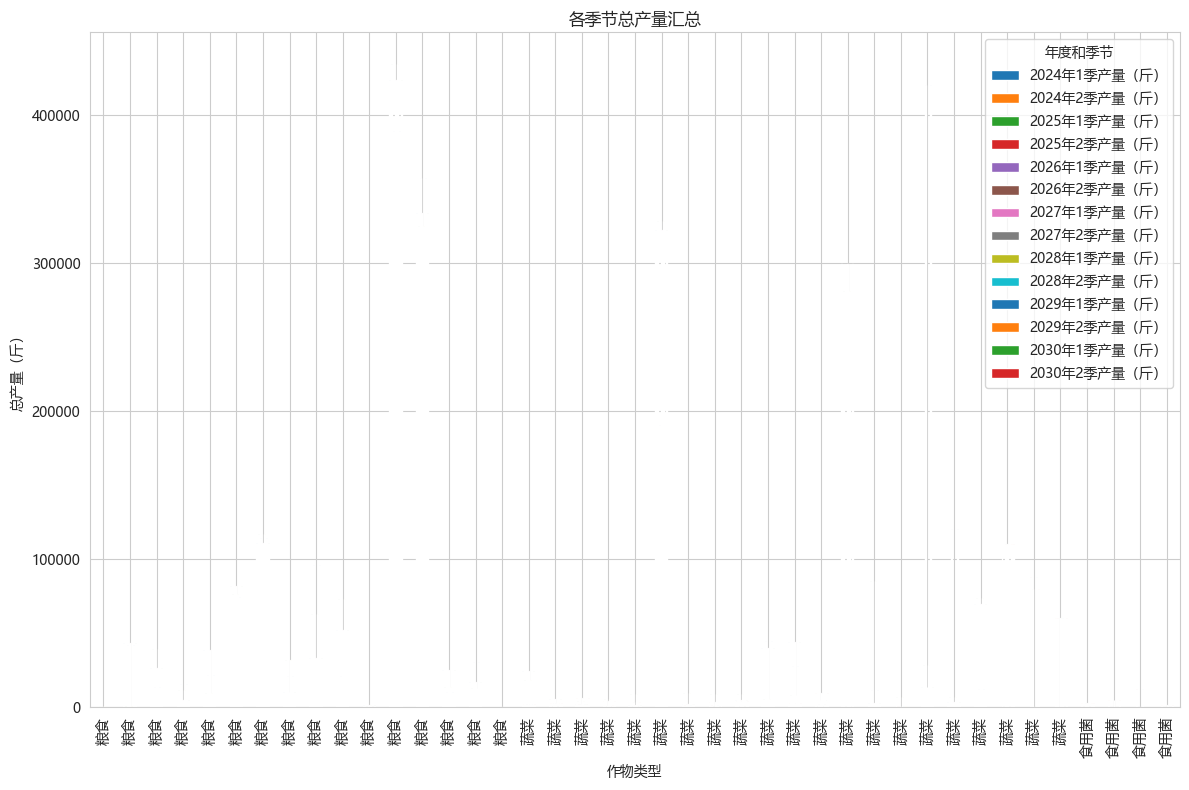

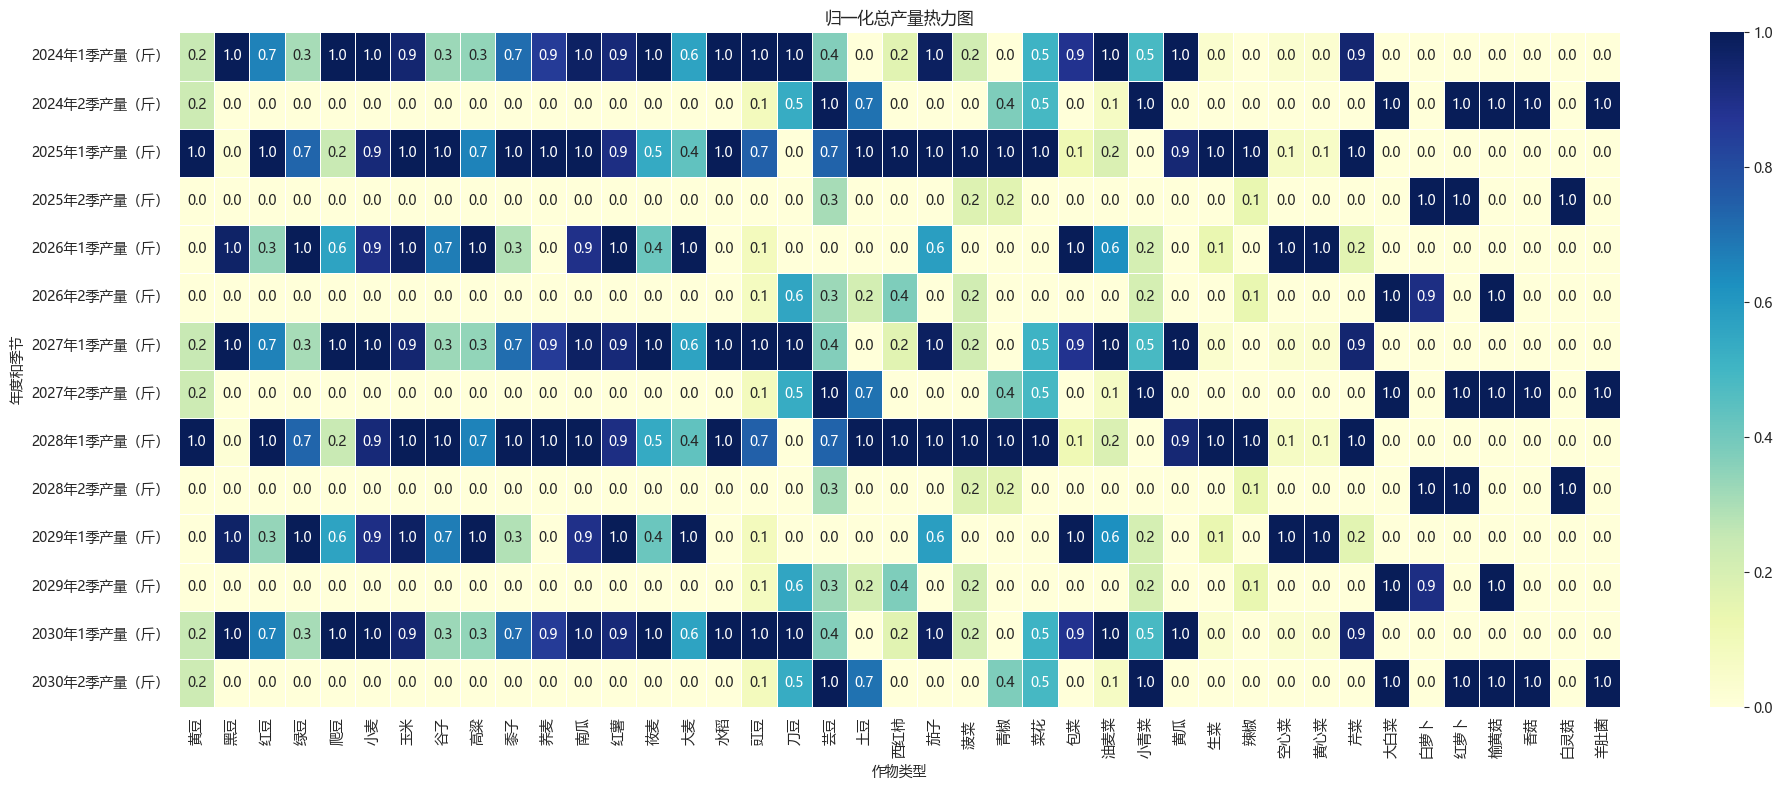

In [55]:
# 平旱地、梯田、山坡每一年只能种植一种作物，并且第二季不种，而且对于种植作物存在要求，必须为非水稻外的粮食类型
for i in range(num_plots): # 开始进行遍历num_plots 也即遍历所有的土地 找到所有num_plots中对应的plot_type为0 1 2 三种类型的土地
    if plot_type[i] in [0, 1, 2]:  #也即找到土地类型为平旱地、梯田、山坡的板块
        for o in [0,2,4]: #这里请注意 py是从0开始计数的 因此0 2 4 分别表示了第1季、第3季、第5季(本文一共考量的是3年的情况 也即6个季节)
            #添加新的约束条件 model +=表示添加约束条件的意思
            model += pulp.lpSum([x[i][j][o] for j in grain_crops]) ==1 # 每块地只能种一种作物，遍历grain_crops中所有的序列并赋值给j，j等于1
            model += pulp.lpSum([x[i][j][o+1] for j in range(num_crops)]) == 0  # 不论第一季是否有种植，第二季节均不能种植任何东西
        model += pulp.lpSum([x[i][j][o] for i in range(num_plots) for j in bean_crops for o in range(time)]) >= 1 #这三年6个季内种植豆类的次数要大于等于1次，确保土地肥沃
        
        for o in range(time):
            model += pulp.lpSum([x[i][j][o] for j in ex_grain_crops]) == 0  # 依据题目要求可知，该三类土地中不能种其他任何的农作物，ex_grain_crops不含水稻
            #用集合的全集减去ex_grain_crops等于所有不符合三类土地要求的农作物，要求自变量遍历这个变量必须保证都为0

    elif plot_type[i] == 3:  # 水浇地 开始遍历到水浇地 
        #水浇地的要求为：水浇地每年可以单季种植水稻或两季种植蔬菜作物
        #若在某块水浇地种植两季蔬菜，第一季可种植多种蔬菜（大白菜、白萝卜和红萝卜除外）；第二季只能种植大白菜、白萝卜和红萝卜中的一种（便于管理）。
        #根据季节性要求，大白菜、白萝卜和红萝卜只能在水浇地的第二季种植。
        for o in [0,2,4]:#在第1、3、5季内
            ##vegetable1_crops是第一季蔬菜集,x[i][45][o]表示水稻
            model += pulp.lpSum([x[i][45][o]]) + pulp.lpSum([x[i][j][o] for j in vegetable1_crops]) == 1
            # 如果种植了水稻，则不需要满足平衡条件，且下一季节水稻不允许种植
            model += pulp.lpSum([x[i][45][o+1]]) == 0  # 在第o+1季节，水稻不允许种植
            # 添加条件约束，若没有种植水稻，则需要满足蔬菜种植量的平衡条件
            model += pulp.lpSum([x[i][j][o] for j in vegetable1_crops]) - pulp.lpSum([x[i][j][o+1] for j in vegetable2_crops]) <= 1 
            # 如果不种水稻，蔬菜种植量需要平衡
            model += pulp.lpSum([x[i][45][o]]) + pulp.lpSum([x[i][j][o] for j in vegetable1_crops]) == 1  # 只能种植一季节的水稻(注意水稻是j=45的作物)和两季节的蔬菜
            model += pulp.lpSum([x[i][45][o]]) + pulp.lpSum([x[i][j][o+1] for j in vegetable2_crops]) <= 1 # 如果在第o季节种植了水稻，则第二季节（o+1）不能种植任何蔬菜
            model += pulp.lpSum([x[i][45][o+1]]) == 0# 若种植了水稻 则不能在继续种植第二季节的蔬菜
            model += pulp.lpSum([x[i][j][o+1] for j in ex_vegetable2_crops]) == 0  # 其余的不能种
            model += pulp.lpSum([x[i][j][o] for j in ex_vegetable1_crops]) == 0  # 其余的不能种
        model += pulp.lpSum([x[i][j][o] for i in range(num_plots) for j in bean_crops for o in range(time)]) >= 1 # 三年内种植豆类次数需要大于等于1

    elif plot_type[i] == 4:  # 普通大棚
        for o in [0,2,4]:
            model += pulp.lpSum([x[i][j][o] for j in vegetable_crops]) == 1  # 一季蔬菜
            model += pulp.lpSum([x[i][j][o+1] for j in fungi_crop]) <=1  # 一季食用菌
            model += pulp.lpSum([x[i][j][o] for j in ex_vegetable_crops]) == 0  # 其余不能种
            model += pulp.lpSum([x[i][j][o+1] for j in ex_fungi_crop]) == 0  # 其余不能种
        
        model += pulp.lpSum([x[i][j][0]+x[i][j][2]+x[i][j][4] for j in bean_crops]) >= 1 # 三年内必须有一次豆类

    elif plot_type[i] == 5:  # 智慧大棚
        for o in [0,2,4]:
            model += pulp.lpSum([x[i][j][o] for j in vegetable1_crops]) == 1  # 第一季蔬菜
            model += pulp.lpSum([x[i][j][o+1] for j in vegetable1_crops]) == 1  # 第二季蔬菜
            model += pulp.lpSum([x[i][j][o] for j in ex_vegetable_crops]) == 0  # 其余不能种
        

            
        model += pulp.lpSum([x[i][j][o] for j in bean_crops for o in range(time)]) == 1 # 三年内必须有一次豆类
# 均衡种植 
for j in range(num_crops):
    model += pulp.lpSum([x[i][j][o] for i in range(num_plots) for o in range(time)]) <= 2
    model += pulp.lpSum([x[i][j][o] for i in range(num_plots) if plot_type[i] == 4 for o in range(time)]) >= 2
model.solve()
output_folder = '问题1_2'
if not os.path.exists(output_folder):
    os.makedirs(output_folder)

# 输出结果
for i in range(num_plots):
    for j in range(num_crops):
        for t in range(6):
            if pulp.value(x[i][j][t]) == 1:
                print(f"正在计算地块 {i} 的第 {t+1} 季种植作物编号为{j} 的种植情况，正在迭代中--------------------")

# 制作结果图表
a = df2[['作物名称', '作物类型']].drop_duplicates()
dic = {i: o for i, o in zip(df2.作物名称, df2.作物类型)}
reward = pd.DataFrame(index=df['作物名称'].unique())
reward['作物类型'] = [dic[i] for i in reward.index]
# 生成2024年到2030年的结果
start_year = 2024
end_year = 2030

# 创建一个ExcelWriter对象，所有结果将写入同一个Excel文件
with pd.ExcelWriter('问题1_2\\result.xlsx', engine='openpyxl', mode='w') as writer:
    for wh in range(3):
        for t in range(6):
            current_year = 2023 + t//2 + 1 + wh*3
            # 仅处理2024年到2030年的数据
            if start_year <= current_year <= end_year:
                result = []
                product = []
                for i in range(num_plots):
                    tem = []
                    product_tem = []
                    for j in range(num_crops):
                        if pulp.value(x[i][j][t]) == 1:
                            tem.append(df1['地块面积/亩'].values[i])
                            product_tem.append(df1['地块面积/亩'].values[i] * df['亩产量/斤'].values[j])
                        else:
                            tem.append(0)
                            product_tem.append(0)

                    result.append(tem)
                    product.append(product_tem)

                # 将结果转为DataFrame
                result_df = pd.DataFrame(result, index=df1['地块名称'].values, columns=df['作物编号'].values).T
                result_df = result_df.groupby(result_df.index).sum().T
                result_df.columns = df['作物名称'].unique()

                # 检测并调整每块地的总种植面积是否超过plot_area[i]
                for i, plot_name in enumerate(result_df.index):
                    total_area = result_df.loc[plot_name].sum()  # 计算该地块所有作物的总种植面积
                    if total_area > plot_area[i]:  # 如果总面积超过限制
                        scale_factor = plot_area[i] / total_area  # 计算缩放因子
                        result_df.loc[plot_name] = result_df.loc[plot_name] * scale_factor  # 进行缩放调整

                # 将调整后的结果写入Excel的不同sheet中
                sheet_name = f'{current_year}年{t%2 + 1}季'
                result_df.to_excel(writer, sheet_name=sheet_name)

                # 计算产量
                product_df = pd.DataFrame(product, index=df1['地块名称'].values, columns=df['作物编号'].values).T
                product_df = product_df.groupby(product_df.index).sum().T
                product_df.columns = df['作物名称'].unique()
                reward[f'{current_year}年{t%2 + 1}季产量（斤）'] = product_df.sum()

# 保存产量到一个独立的sheet
with pd.ExcelWriter('问题1_2\\result.xlsx', engine='openpyxl', mode='a') as writer:
    reward.to_excel(writer, sheet_name='总产量')

# 绘制结果图像
for wh in range(3):
    for t in range(6):
        current_year = 2023 + t//2 + 1 + wh*3
        if start_year <= current_year <= end_year:
            sheet_name = f'{current_year}年{t%2 + 1}季'
            result_df = pd.read_excel('问题1_2\\result.xlsx', sheet_name=sheet_name, index_col=0)    
            # 绘制每个地块的总产量柱状图
            total_yield = result_df.sum(axis=1)
            total_yield.plot(kind='bar', figsize=(10, 6))
            plt.title(f'{sheet_name} 每块地的总产量')
            plt.xlabel('地块名称')
            plt.ylabel('总产量（斤）')
            plt.tight_layout()
            plt.savefig(f'问题1_2\\{sheet_name}_总产量.png')
            plt.close()

# 绘制总产量汇总图
reward.set_index('作物类型').plot(kind='bar', figsize=(12, 8))
plt.title('各季节总产量汇总')
plt.xlabel('作物类型')
plt.ylabel('总产量（斤）')
plt.legend(title='年度和季节')
plt.tight_layout()
plt.savefig('问题1_2总产量汇总.png')
plt.show()

# 绘制总产量热力图
heatmap_data = reward.drop(columns='作物类型').T  # 转置以适应热力图的格式
scaler = MinMaxScaler()
normalized_heatmap_data = pd.DataFrame(scaler.fit_transform(heatmap_data), index=heatmap_data.index, columns=heatmap_data.columns)

plt.figure(figsize=(20, 8))
sns.heatmap(normalized_heatmap_data, annot=True, fmt='.1f', cmap='YlGnBu', linewidths=0.5)
plt.title('归一化总产量热力图')
plt.xlabel('作物类型')
plt.ylabel('年度和季节')
plt.tight_layout()
plt.savefig('问题1_2归一化总产量热力图.png')
plt.show()